In [1]:
import numpy as np
import os
from matplotlib import pyplot as plt
import matplotlib as mpl

g = 9.805
mpl.rc('font',family='Times New Roman')

In [2]:
def Gamma(D1):
    s = 0
    ss = 0
    for i in range(len(D1)):
        s = D1[i]*m[i] + s
        ss = D1[i]**2*m[i] + ss
    return s/ss, s**2/ss

In [3]:
m = [0, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.0, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.0,
     0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.0,
     0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.0] 

In [4]:
im = 9

In [5]:
model = 'M63_biron'

In [6]:
dispX = np.loadtxt(model+"_DispX.txt")
dispY = np.loadtxt(model+"_DispY.txt")

In [7]:
Dxm = np.zeros(10)
Dym = np.zeros(10)

for i in range(len(Dxm)):
    dx = dispX[:,i]
    dx = dx[dx != 0]
    Dxm[i] = np.median(dx)
    
    dy = dy = dispY[:,i]
    dy = dy[dy != 0]
    Dym[i] = np.median(dy)

In [8]:
data = np.load("M63_peak_displacements.npy", allow_pickle=True).item()

dispXs = data["dispXs"]
dispYs = data["dispYs"]

In [9]:
DxmS = np.zeros(10)
DymS = np.zeros(10)

for i in range(10):
    DxmS[i] = np.median(dispXs[:,i])
    DymS[i] = np.median(dispYs[:,i])


Text(0, 0.5, 'Peak Suspended Piping Displacement')

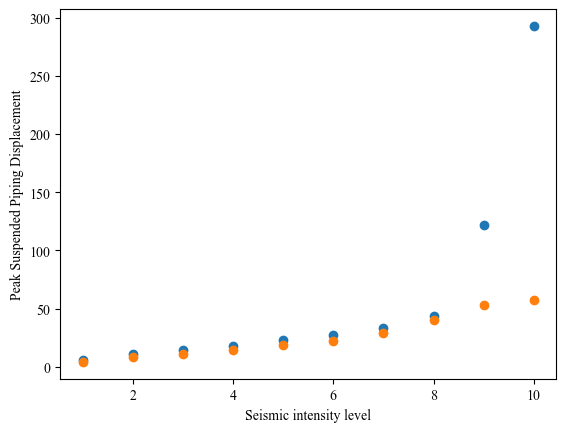

In [10]:
im = [1,2,3,4,5,6,7,8,9,10]
plt.scatter(im,Dxm)
plt.scatter(im,DxmS*0.87*1.23)
plt.xlabel('Seismic intensity level')
plt.ylabel('Peak Suspended Piping Displacement')

Text(0, 0.5, 'Peak Suspended Piping Displacement')

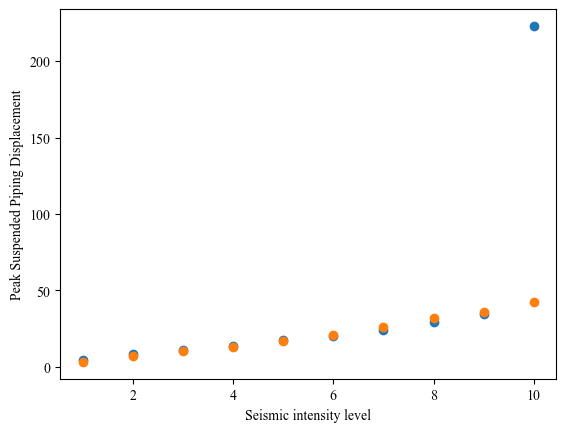

In [11]:

#plt.scatter(im,Dxm)
plt.scatter(im,Dym)
plt.scatter(im,DymS*1.102*1.05)
plt.xlabel('Seismic intensity level')
plt.ylabel('Peak Suspended Piping Displacement')

Text(0, 0.5, 'MRE')

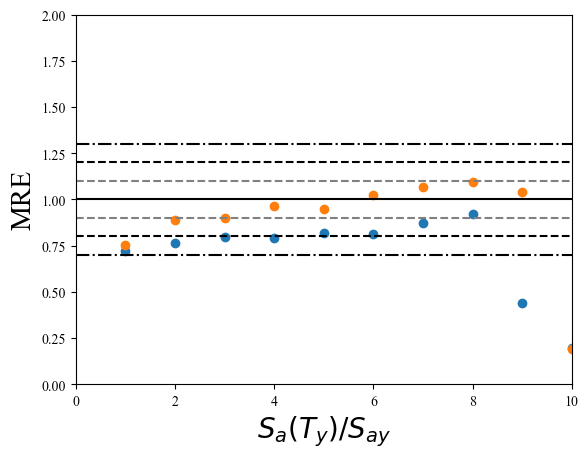

In [12]:
plt.scatter(im,DxmS*0.87*1.23/Dxm)
plt.scatter(im,DymS*1.102*1.05/Dym)

plt.plot((0,10),(1.1,1.1),color='grey',ls='--')
plt.plot((0,10),(0.9,0.9),color='grey',ls='--')

plt.plot((0,10),(1.2,1.2),color='k',ls='--')
plt.plot((0,10),(0.8,0.8),color='k',ls='--')

plt.plot((0,10),(1.3,1.3),color='k',ls='-.')
plt.plot((0,10),(0.7,0.7),color='k',ls='-.')

plt.plot((0,10),(1,1),color='k')
plt.ylim(0,2)
plt.xlim(0,10)
plt.xlabel(r'$S_{a}(T_y)/S_{ay}$',fontsize=20)
plt.ylabel(r'MRE',fontsize=20)

In [13]:
DispShapeX = np.load(model+"DispShapeX.npy")
DispShapeY = np.load(model+"DispShapeY.npy")

In [14]:
def DispShapeStat(DispShapeX,DispShapeY):
    tol = 0
    mask_rowsX = np.any(DispShapeX > tol, axis=(1))
    mask_rowsY = np.any(DispShapeY > tol, axis=(1))
    
    DispShapeX_no_zero = DispShapeX[mask_rowsX, :]
    DispShapeY_no_zero = DispShapeY[mask_rowsY, :]
    
    DSXm = DispShapeX_no_zero.mean(axis=0)
    DSYm = DispShapeY_no_zero.mean(axis=0)
    
    DSXs = DispShapeX_no_zero.std(axis=0)
    DSYs = DispShapeY_no_zero.std(axis=0)

    return DSXm,DSYm,DSXs,DSYs

In [15]:
DSXm = np.zeros((66,10))
DSYm = np.zeros((66,10))

DSXs = np.zeros((66,10))
DSYs = np.zeros((66,10))

for i in range(10):
    DSXm[:,i],DSYm[:,i],DSXs[:,i],DSYs[:,i] = DispShapeStat(DispShapeX[:,:,i],DispShapeY[:,:,i])

In [16]:

POy = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover2D/pushover_results_M63y.txt')
POx = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover2D/pushover_results_M63x.txt')

In [17]:
Vbx_SDOF = -1*np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover_SDOF/ResultsM63x_SDOF/VbaseC.out')
Dx_SDOF = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover_SDOF/ResultsM63x_SDOF/DispC.out')

In [18]:
Vby_SDOF = -1*np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover_SDOF/ResultsM63y_SDOF/VbaseC.out')
Dy_SDOF = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover_SDOF/ResultsM63y_SDOF/DispC.out')

In [19]:
Fx_3D = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover/ResultsM63_biron/ReactionsX.out')

Vbx_3D = np.zeros(len(Fx_3D[:,0]))
for i in range(len(Vbx_3D)):
    Vbx_3D[i] = -1*np.sum(Fx_3D[i,1:])

Dx_3D = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover/ResultsM63_biron/PipeNodeDispX.out')

Dx3D_eq = np.zeros(len(Dx_3D[:,0]))
for i in range(len(Dx3D_eq)):
    Dx3D_eq[i] = np.sum(Dx_3D[i,1:]**2)/np.sum(Dx_3D[i,1:])

In [20]:
Fy_3D = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover/ResultsM63_biron/ReactionsY.out')

Vby_3D = np.zeros(len(Fy_3D[:,0]))
for i in range(len(Vby_3D)):
    Vby_3D[i] = -1*np.sum(Fy_3D[i,1:])

Dy_3D = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover/ResultsM63_biron/PipeNodeDispY.out')

Dy3D_eq = np.zeros(len(Dy_3D[:,0]))
for i in range(len(Dy3D_eq)):
    Dy3D_eq[i] = np.sum(Dy_3D[i,1:]**2)/np.sum(Dy_3D[i,1:])

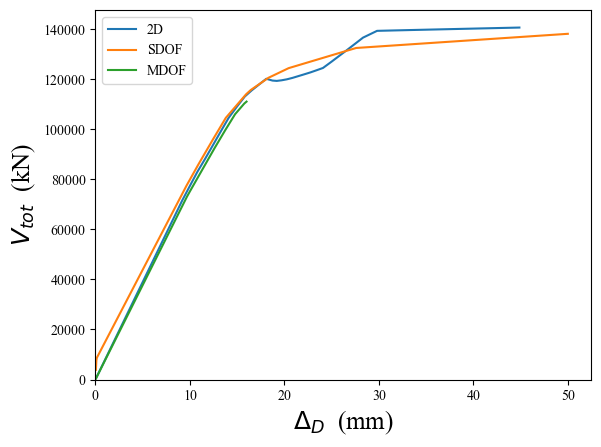

In [21]:
plt.plot(POx[:,5],POx[:,3]*2,label='2D') 
plt.plot(Dx_SDOF,Vbx_SDOF,label='SDOF')
plt.plot(Dx3D_eq,Vbx_3D,label='MDOF')

plt.xlabel(r'$\Delta_{D}$  (mm)',fontsize=18)
plt.ylabel(r'$V_{tot}$  (kN)',fontsize=18)
plt.xlim(0)
plt.ylim(0)
plt.legend()

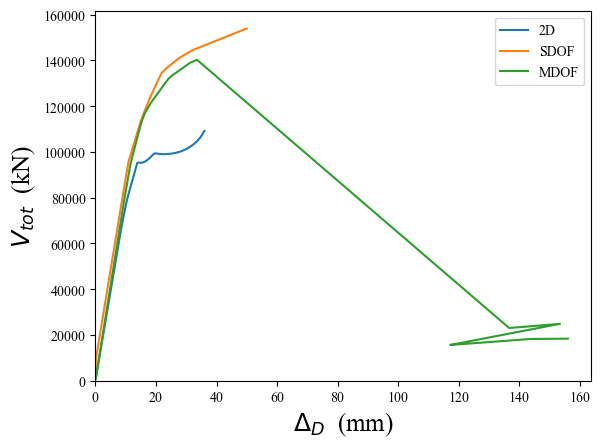

In [22]:
plt.plot(POy[:,5],POy[:,3],label='2D')
plt.plot(Dy_SDOF,Vby_SDOF,label='SDOF')
plt.plot(Dy3D_eq,Vby_3D,label='MDOF')

plt.xlabel(r'$\Delta_{D}$  (mm)',fontsize=18)
plt.ylabel(r'$V_{tot}$  (kN)',fontsize=18)
plt.xlim(0)
plt.ylim(0)
plt.legend()

In [23]:
#Dstaticx = POx[:,6:24]
Dstaticx = np.flip(POx[20,6:24])

In [25]:
im =9

In [26]:
Dstaticy = POy[:,6:35]


In [29]:
x0m = np.zeros(30)
y0m = np.zeros(30)


x0m[0] = 0.0
x0m[1] = 1.0
x0m[2] = 4.0
x0m[3] = 7.0
x0m[4] = 10.0
x0m[5] = 13.0
x0m[6] = 16.0
x0m[7] = 19.0
x0m[8] = 22.0
x0m[9] = 25.0
x0m[10] = 28.0
x0m[11] = 31.0
x0m[12] = 32.0
x0m[13] = 34.0
x0m[14] = 37.0
x0m[15] = 40.0
x0m[16] = 43.0
x0m[17] = 46.0
x0m[18] = 49.0
x0m[19] = 52.0
x0m[20] = 55.0
x0m[21] = 58.0
x0m[22] = 61.0
x0m[23] = 64.0
x0m[24] = 67.0
x0m[25] = 70.0
x0m[26] = 73.0
x0m[27] = 76.0
x0m[28] = 79.0
x0m[29] = 82.0


In [30]:
x0b1 = 82*np.ones(19)
y0b1 = np.zeros(19)

y0b1[1] = 1.0
for i in range(2,19):
    y0b1[i] = y0b1[1]+3*(i-1)

x0b2 = 32*np.ones(19)
y0b2 = np.zeros(19)

y0b2[1] = 1.0
for i in range(2,19):
    y0b2[i] = y0b2[1]+3*(i-1)

In [31]:
DSXML = DSXm[:30,im]
DSXBL1 = DSXm[30:48,im]
DSXBL2 = DSXm[48:66,im]

In [32]:
DSXMLs = DSXs[:30,im]
DSXBL1s = DSXs[30:48,im]
DSXBL2s = DSXs[48:66,im]

In [33]:
DSXBL1 = np.insert(DSXBL1,0,DSXm[19,im])
DSXBL2 = np.insert(DSXBL2,0,DSXm[29,im])

In [34]:
DSXBL1s = np.insert(DSXBL1s,0,DSXs[19,im])
DSXBL2s = np.insert(DSXBL2s,0,DSXs[29,im])

In [35]:
DSYML = DSYm[:30,im]
DSYBL1 = DSYm[30:48,im]
DSYBL2 = DSYm[48:66,im]

In [36]:
DSYMLs = DSYs[:30,im]
DSYBL1s = DSYs[30:48,im]
DSYBL2s = DSYs[48:66,im]

In [37]:
DSYBL1 = np.insert(DSYBL1,0,DSYm[19,im])
DSYBL2 = np.insert(DSYBL2,0,DSYm[29,im])

In [38]:
DSYBL1s = np.insert(DSYBL1s,0,DSYs[19,im])
DSYBL2s = np.insert(DSYBL2s,0,DSYs[29,im])

In [39]:
dsdxm = np.ones(len(x0m))
dsdxb = np.ones(len(x0b1))

dsdxb = np.multiply(dsdxb,np.append(0,Dstaticx))

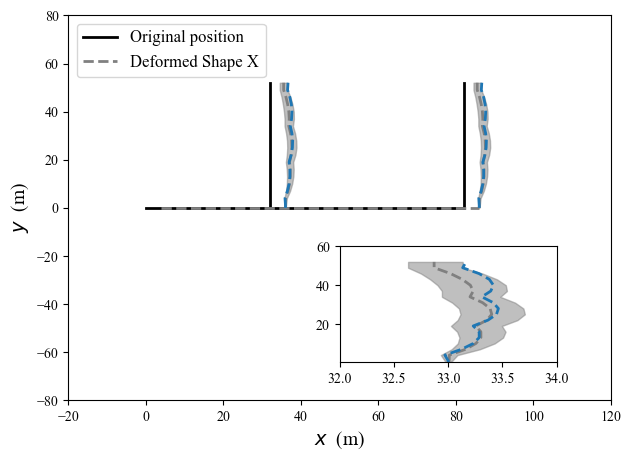

In [40]:
fig, ax = plt.subplots(ncols=1,figsize=(7,5))

ax.plot(x0m,y0m, color='k',lw=2,label='Original position')

ax.plot(x0b1,y0b1, color='k',lw=2)
ax.plot(x0b2,y0b2, color='k',lw=2)

ampx = 4
ax.plot(x0m+ampx*DSXML,y0m, color='grey',lw=2, ls='--',label='Deformed Shape X')
ax.plot(x0b1+ampx*DSXBL1,y0b1, color='grey',lw=2, ls='--')
ax.plot(x0b2+ampx*DSXBL2,y0b2, color='grey',lw=2, ls='--')

ax.plot(x0b1+ampx*np.append(Dstaticx[0],Dstaticx),y0b1, color='C0',lw=2, ls='--')
ax.plot(x0b2+ampx*np.append(Dstaticx[0],Dstaticx),y0b2, color='C0',lw=2, ls='--')
ax.fill_betweenx(y0b2,x0b2+ampx*(DSXBL2+2*DSXBL2s),x0b2+ampx*(DSXBL2-2*DSXBL2s),color='grey',alpha=0.5)
ax.fill_betweenx(y0b1,x0b1+ampx*(DSXBL2+2*DSXBL2s),x0b1+ampx*(DSXBL2-2*DSXBL2s),color='grey',alpha=0.5)

axins1 = ax.inset_axes([0.5, 0.1, 0.4, 0.3],xlim=(32,34), ylim=(0.5, 60))
axins1.plot(x0b2+DSXBL1,y0b2, color='grey',lw=2, ls='--')
axins1.plot(x0b2+np.append(Dstaticx[0],Dstaticx),y0b2, color='C0',lw=2, ls='--')
axins1.fill_betweenx(y0b2,x0b2+(DSXBL2+2*DSXBL2s),x0b2+(DSXBL2-2*DSXBL2s),color='grey',alpha=0.5)
#axins1.fill_between(x0b1,y0b1+(DSYb1m[:,im]+2*DSYs[:,im]),y0+(DSYm[:,im]-2*DSYs[:,im]),color='grey',alpha=0.5)
#axins1.plot(x0,y0+dsdy, color='C0',ls='--',label='Displaced shape Static')

ax.set_xlim(-20, 120)
ax.set_ylim(-80,80)
ax.set_ylabel(r'$y$  (m)',fontsize=14)
ax.set_xlabel(r'$x$  (m)',fontsize=14)

ax.legend(fontsize=12,loc=2)

In [41]:
Gx_NLTH, mx_NLTH = Gamma(DSXm[:,5])
Gx_NLTH

0.8500882114333211

In [42]:
mx_NLTH/np.sum(m)

0.9740373914988615

In [43]:
mx_NLTH

21.984023926129307

In [44]:
np.sum(m)

22.570000000000004

In [45]:
Gx_static = POx[10,1]
Gx_static

0.868

In [46]:
mx_static = POx[10,2]
mx_static

22.681

In [47]:
POx[10,4]*np.sum(m)

22.186310000000002

In [48]:
abs(Gx_static-Gx_NLTH)/Gx_NLTH

0.02107050577313389

In [49]:
abs(mx_static-mx_NLTH)/mx_NLTH

0.0317037534262459

In [50]:
Dstaticx

array([1.   , 0.969, 1.123, 1.231, 1.285, 1.285, 1.23 , 1.366, 1.445,
       1.462, 1.415, 1.31 , 1.392, 1.416, 1.379, 1.283, 1.133, 1.165])

In [51]:
np.append(Dstaticy[6,0],Dstaticy[6,:])

array([0.314, 0.314, 0.433, 0.505, 0.521, 0.479, 0.602, 0.658, 0.642,
       0.555, 0.657, 0.688, 0.699, 0.661, 0.853, 0.957, 0.961, 0.866,
       1.073, 1.169, 1.144, 1.001, 1.206, 1.287, 1.234, 1.054, 1.241,
       1.3  , 0.689, 1.   ])

In [53]:
dsdy = np.ones(len(y0m))

dsdy = np.multiply(dsdy,np.append(Dstaticy[6,0],Dstaticy[6,:]))

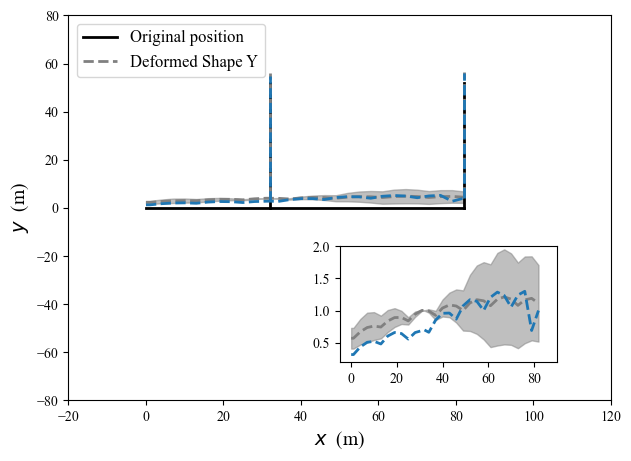

In [54]:
fig, ax = plt.subplots(ncols=1,figsize=(7,5))
ax.plot(x0m,y0m, color='k',lw=2,label='Original position')

ax.plot(x0b1,y0b1, color='k',lw=2)
ax.plot(x0b2,y0b2, color='k',lw=2)

ampx = 4
ax.plot(x0m,y0m+ampx*DSYML, color='grey',lw=2, ls='--',label='Deformed Shape Y')
ax.plot(x0b1,y0b1+ampx*DSYBL1, color='grey',lw=2, ls='--')
ax.plot(x0b2,y0b2+ampx*DSYBL2, color='grey',lw=2, ls='--')

ax.plot(x0m,y0m+ampx*dsdy, color='C0',lw=2, ls='--')
ax.plot(x0b1,y0b1+ampx*dsdy[-1]*np.ones(len(y0b1)), color='C0',lw=2, ls='--')
ax.plot(x0b2,y0b2+ampx*dsdy[12]*np.ones(len(y0b2)), color='C0',lw=2, ls='--')
ax.fill_between(x0m,y0m+ampx*(DSYML+2*DSYMLs),y0m+ampx*(DSYML-2*DSYMLs),color='grey',alpha=0.5)

axins1 = ax.inset_axes([0.5, 0.1, 0.4, 0.3],xlim=(-5,90), ylim=(0.2, 2))
axins1.plot(x0m,y0m+DSYML, color='grey',lw=2, ls='--')
axins1.plot(x0m,y0m+dsdy, color='C0',lw=2, ls='--')
axins1.fill_between(x0m,y0m+(DSYML+2*DSYMLs),y0m+(DSYML-2*DSYMLs),color='grey',alpha=0.5)

ax.set_xlim(-20, 120)
ax.set_ylim(-80,80)
ax.set_ylabel(r'$y$  (m)',fontsize=14)
ax.set_xlabel(r'$x$  (m)',fontsize=14)

plt.legend(fontsize=12)

In [54]:
Gy_NLTH, my_NLTH = Gamma(DSYm[:,5])
Gy_NLTH

0.9955310016147267

In [55]:
modal_my_NLTH = my_NLTH/np.sum(m)

In [56]:
my_NLTH

22.37340310652511

In [57]:
Gy_static = POy[10,1]
Gy_static

1.102

In [58]:
my_static = POy[10,2]
my_static

21.656

In [59]:
modal_my_static = POy[10,4]
modal_my_static*np.sum(m)

21.125520000000005

In [60]:
abs(Gy_static-Gy_NLTH)/Gy_NLTH

0.10694694410579204

In [61]:
abs(modal_my_NLTH-modal_my_static)/my_NLTH

0.002471213676583682

In [62]:
Dstaticy[10,:]

array([0.314, 0.433, 0.505, 0.521, 0.479, 0.602, 0.658, 0.642, 0.555,
       0.657, 0.688, 0.689, 0.699, 0.661, 0.853, 0.957, 0.961, 0.866,
       1.073, 1.169, 1.144, 1.001, 1.206, 1.287, 1.234, 1.054, 1.241,
       1.3  , 1.   ])

In [63]:
dsdy

array([0.314, 0.314, 0.433, 0.505, 0.521, 0.479, 0.602, 0.658, 0.642,
       0.555, 0.657, 0.688, 0.689, 0.699, 0.661, 0.853, 0.957, 0.961,
       0.866, 1.073, 1.169, 1.144, 1.001, 1.206, 1.287, 1.234, 1.054,
       1.241, 1.3  , 1.   ])